In [5]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("C:/Users/Divya Nehete/AI-Exposure-Predictor/data/cleaned/cleaned_dataset.csv")

df.head()

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,SOC Code,Occupation Title,AIOE
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
1,11-1011.00,Chief Executives,8824,"Confer with board members, organization offici...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
2,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,94.0,08/2023,Incumbent,11-1011,Chief Executives,1.334
4,11-1011.00,Chief Executives,8834,Prepare or present reports concerning activiti...,Core,95.0,08/2023,Incumbent,11-1011,Chief Executives,1.334


In [6]:
print(df.shape)

(15814, 11)


In [7]:
df.columns

Index(['O*NET-SOC Code', 'Title', 'Task ID', 'Task', 'Task Type',
       'Incumbents Responding', 'Date', 'Domain Source', 'SOC Code',
       'Occupation Title', 'AIOE'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15814 entries, 0 to 15813
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   O*NET-SOC Code         15814 non-null  str    
 1   Title                  15814 non-null  str    
 2   Task ID                15814 non-null  int64  
 3   Task                   15814 non-null  str    
 4   Task Type              15560 non-null  str    
 5   Incumbents Responding  15319 non-null  float64
 6   Date                   15814 non-null  str    
 7   Domain Source          15814 non-null  str    
 8   SOC Code               15814 non-null  str    
 9   Occupation Title       15814 non-null  str    
 10  AIOE                   15814 non-null  float64
dtypes: float64(2), int64(1), str(8)
memory usage: 4.5 MB


In [10]:
#Select relevant columns
# Select only the columns required for feature engineering

df = df[
    [
        "Occupation Title",
        "Task",
        "Task Type",
        "Incumbents Responding",
        "AIOE"
    ]
]

# Display first few rows
df.head()

,Occupation Title,Task,Task Type,Incumbents Responding,AIOE
0,Chief Executives,Direct or coordinate an organization's financi...,Core,95.0,1.334
1,Chief Executives,"Confer with board members, organization offici...",Core,95.0,1.334
2,Chief Executives,"Prepare budgets for approval, including those ...",Core,95.0,1.334
3,Chief Executives,"Direct, plan, or implement policies, objective...",Core,94.0,1.334
4,Chief Executives,Prepare or present reports concerning activiti...,Core,95.0,1.334


In [11]:
print(df.shape)
print(df.columns)

(15814, 5)
Index(['Occupation Title', 'Task', 'Task Type', 'Incumbents Responding',
       'AIOE'],
      dtype='str')


In [12]:
#Clean the task text by removing punctuation, numbers, and converting to lowercase
import re

def clean_text(text):
    text = str(text).lower()                 # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

# Create cleaned task column
df["Clean_Task"] = df["Task"].apply(clean_text)

# Preview
df[["Task", "Clean_Task"]].head()

,Task,Clean_Task
0,Direct or coordinate an organization's financi...,direct or coordinate an organizations financia...
1,"Confer with board members, organization offici...",confer with board members organization officia...
2,"Prepare budgets for approval, including those ...",prepare budgets for approval including those f...
3,"Direct, plan, or implement policies, objective...",direct plan or implement policies objectives o...
4,Prepare or present reports concerning activiti...,prepare or present reports concerning activiti...


In [13]:
#Check for missing values in the cleaned task column
df["Clean_Task"].isnull().sum()

np.int64(0)

In [14]:
print(df.columns.tolist())

['Occupation Title', 'Task', 'Task Type', 'Incumbents Responding', 'AIOE', 'Clean_Task']


In [15]:
#Convert task text into numerical features using TF-IDF Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

# Transform cleaned task descriptions
X_text = tfidf.fit_transform(df["Clean_Task"])

print("TF-IDF Matrix Shape:", X_text.shape)

TF-IDF Matrix Shape: (15814, 1000)


In [16]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['abreast' 'academic' 'access' 'accessories' 'accordance' 'according'
 'accounting' 'accounts' 'accuracy' 'accurate' 'achieve' 'act' 'action'
 'actions' 'activities' 'activity' 'additional' 'address' 'adherence'
 'adjust' 'adjusting' 'adjustments' 'administer' 'administration'
 'administrative' 'advertising' 'advice' 'advise' 'advisers' 'agencies']


Encode Task type
The Task Type column is categorical. Machine learning models require numerical values, so the categories are converted into binary variables using One-Hot Encoding.

In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

X_tasktype = encoder.fit_transform(df[["Task Type"]])

print("Encoded Task Type Shape:", X_tasktype.shape)

Encoded Task Type Shape: (15814, 3)


In [18]:
print(encoder.categories_)

[array(['Core', 'Supplemental', nan], dtype=object)]


Scale Numerical Feature

The Incumbents Responding variable has a much larger numerical range than the encoded text features. Standardization ensures that all numerical variables contribute proportionally during model training.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num = scaler.fit_transform(df[["Incumbents Responding"]].fillna(0))

print(X_num.shape)

(15814, 1)


Combine All Features

The text features, categorical variables, and numerical variables are combined into a single feature matrix. This unified dataset represents every task using all relevant information required for machine learning.

In [20]:
from scipy.sparse import hstack

# Combine all features
X = hstack([
    X_text,
    X_tasktype,
    X_num
])

print("Final Feature Matrix Shape:", X.shape)

Final Feature Matrix Shape: (15814, 1004)


Prepare the Target Variable

The AIOE (AI Occupational Exposure) score is selected as the target variable because it represents the degree to which each task is exposed to AI technologies.

In [21]:
y = df["AIOE"]

print(y.describe())

count    15814.000000
mean         0.100558
std          0.978604
min         -2.670000
25%         -0.761000
50%          0.124000
75%          1.031000
max          1.528000
Name: AIOE, dtype: float64


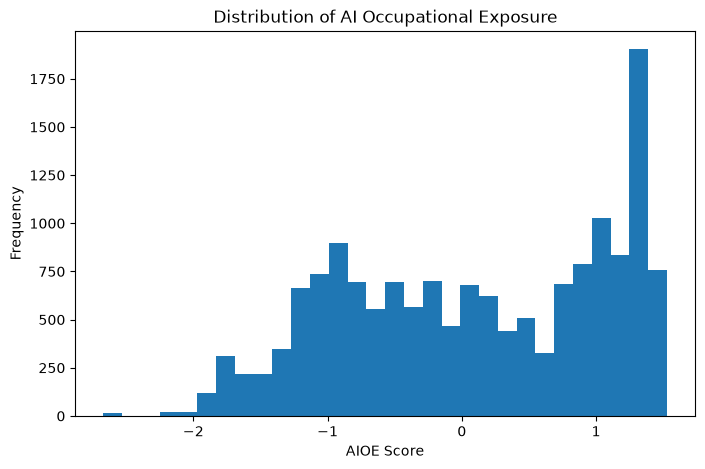

In [22]:
#Check Distribution of target variable
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y, bins=30)
plt.xlabel("AIOE Score")
plt.ylabel("Frequency")
plt.title("Distribution of AI Occupational Exposure")
plt.show()

In [ ]:
Save the Processed Dataset
The engineered features and target variable are saved for reuse during model development in Week 4.
 Saving intermediate outputs avoids repeating computationally intensive preprocessing steps.

In [23]:
import joblib

# Save feature matrix
joblib.dump(X, "../data/processed/X_features.pkl")

# Save target variable
joblib.dump(y, "../data/processed/y_target.pkl")

# Save TF-IDF vectorizer
joblib.dump(tfidf, "../data/processed/tfidf_vectorizer.pkl")

# Save encoder
joblib.dump(encoder, "../data/processed/tasktype_encoder.pkl")

# Save scaler
joblib.dump(scaler, "../data/processed/scaler.pkl")

print("Week 3 outputs saved successfully!")

Week 3 outputs saved successfully!
